# **Assignment 12: Random Forest, Bagging & Boosting**

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

**Task 1: Exploratory Data Analysis**

In [18]:
df_glass = pd.read_excel("/content/glass.xlsx", sheet_name="glass")

print("--- Dataset Shape ---")
print(df_glass.shape)

print("\n--- Summary Statistics ---")
print(df_glass.describe())

print("\n--- Missing Values Count ---")
print(df_glass.isnull().sum())

print("\n--- Class Distribution (Target: Type) ---")
print(df_glass["Type"].value_counts())

# Outlier Detection using Interquartile Range (IQR)
feature_cols = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe"]
print("\n--- Outlier Detection ---")
for col in feature_cols:
    Q1 = df_glass[col].quantile(0.25)
    Q3 = df_glass[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_glass[
        (df_glass[col] < Q1 - 1.5 * IQR) | (df_glass[col] > Q3 + 1.5 * IQR)
    ]
    print(f"Feature '{col}': {len(outliers)} outliers detected.")

--- Dataset Shape ---
(214, 10)

--- Summary Statistics ---
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439 

**Task 2: Data Visualization**

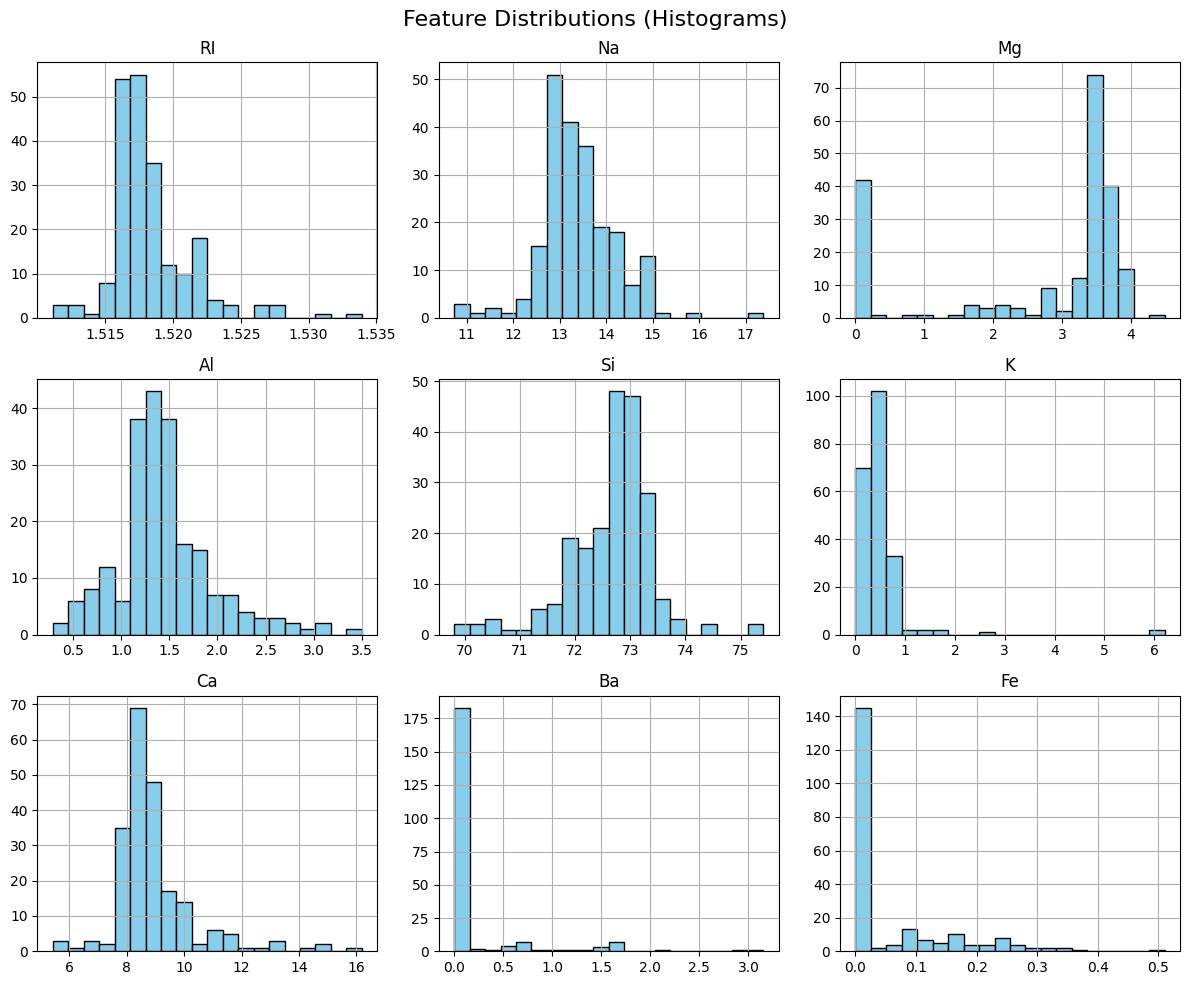

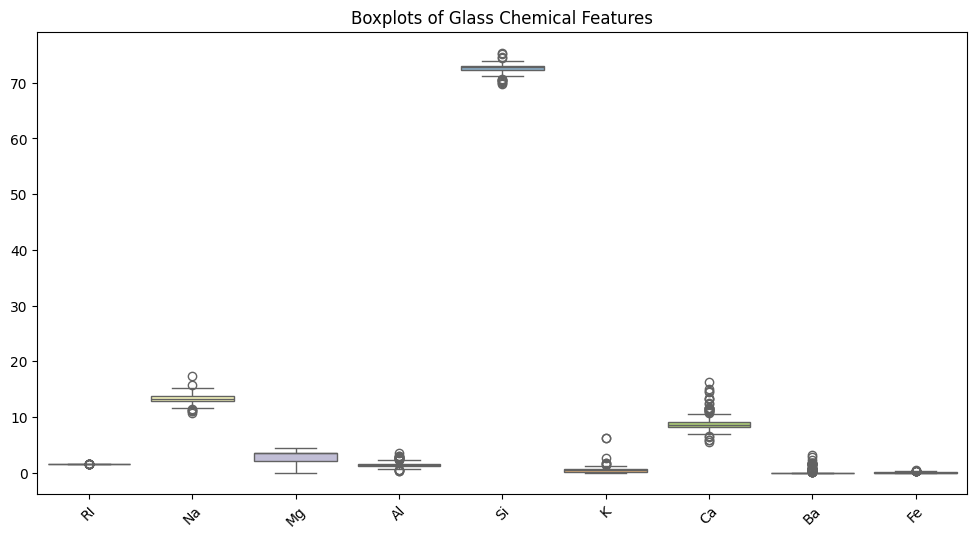

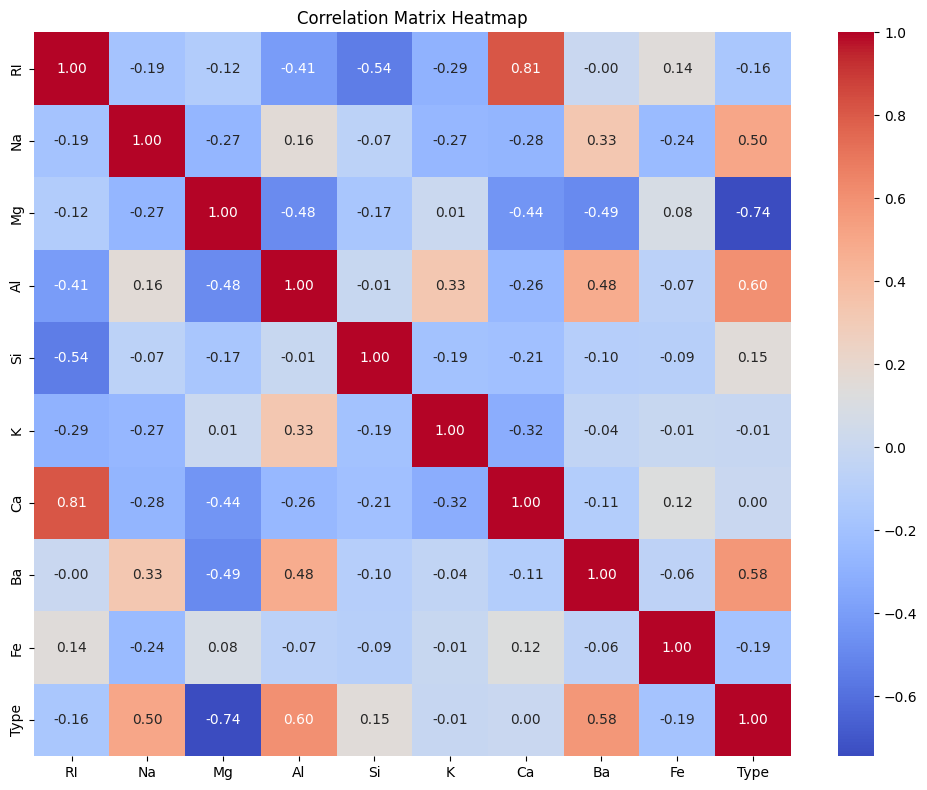

In [19]:
df_glass[feature_cols].hist(
    figsize=(12, 10), bins=20, color="skyblue", edgecolor="black"
)
plt.suptitle("Feature Distributions (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots for Outlier Visualisation
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_glass[feature_cols], palette="Set3")
plt.title("Boxplots of Glass Chemical Features")
plt.xticks(rotation=45)
plt.show()

# Feature Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_glass.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

**Task 3: Data Preprocessing**

In [20]:
X = df_glass[feature_cols]
y = df_glass["Type"]

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reset index on split arrays to guarantee exact index alignment during oversampling
X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

# Combine into training DataFrame for oversampling
train_data = pd.concat([X_train_reset, y_train_reset], axis=1)
max_size = train_data["Type"].value_counts().max()

# Resample minority classes to balance class frequencies
balanced_dfs = []
for glass_type, group in train_data.groupby("Type"):
    if len(group) < max_size:
        group_oversampled = resample(
            group, replace=True, n_samples=max_size, random_state=42
        )
        balanced_dfs.append(group_oversampled)
    else:
        balanced_dfs.append(group)

train_balanced = pd.concat(balanced_dfs, ignore_index=True)
X_train_bal = train_balanced.drop(columns=["Type"])
y_train_bal = train_balanced["Type"]

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

**Task 4: Random Forest Model Implementation**


--- Random Forest Model Evaluation ---
Accuracy : 0.813953488372093
Precision: 0.8424567680381634
Recall   : 0.813953488372093
F1-Score : 0.8218665055874358


/tmp/ipykernel_2288/1093871752.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis")


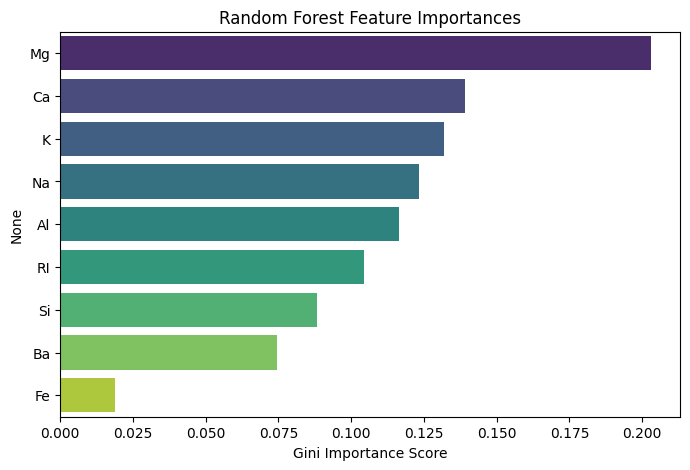

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal_scaled, y_train_bal)

y_pred_rf = rf_model.predict(X_test_scaled)

print("\n--- Random Forest Model Evaluation ---")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(
    "Precision:",
    precision_score(y_test, y_pred_rf, average="weighted", zero_division=0),
)
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1-Score :", f1_score(y_test, y_pred_rf, average="weighted"))

# Visualizing Random Forest Feature Importances
plt.figure(figsize=(8, 5))
feature_imp = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis")
plt.title("Random Forest Feature Importances")
plt.xlabel("Gini Importance Score")
plt.show()

**Task 5: Bagging and Boosting Methods Comparison**

In [22]:
# 1. Bagging Classifier
bagging_model = BaggingClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train_bal_scaled, y_train_bal)
y_pred_bag = bagging_model.predict(X_test_scaled)

# 2. Gradient Boosting Classifier
boosting_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting_model.fit(X_train_bal_scaled, y_train_bal)
y_pred_boost = boosting_model.predict(X_test_scaled)

# Performance Comparison Table
comparison_df = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            "Accuracy": accuracy_score(y_test, y_pred_rf),
            "Precision": precision_score(
                y_test, y_pred_rf, average="weighted", zero_division=0
            ),
            "Recall": recall_score(y_test, y_pred_rf, average="weighted"),
            "F1-Score": f1_score(y_test, y_pred_rf, average="weighted"),
        },
        {
            "Model": "Bagging Classifier",
            "Accuracy": accuracy_score(y_test, y_pred_bag),
            "Precision": precision_score(
                y_test, y_pred_bag, average="weighted", zero_division=0
            ),
            "Recall": recall_score(y_test, y_pred_bag, average="weighted"),
            "F1-Score": f1_score(y_test, y_pred_bag, average="weighted"),
        },
        {
            "Model": "Gradient Boosting",
            "Accuracy": accuracy_score(y_test, y_pred_boost),
            "Precision": precision_score(
                y_test, y_pred_boost, average="weighted", zero_division=0
            ),
            "Recall": recall_score(y_test, y_pred_boost, average="weighted"),
            "F1-Score": f1_score(y_test, y_pred_boost, average="weighted"),
        },
    ]
)

print("\n--- Model Performance Comparison ---")
print(comparison_df.to_string(index=False))


--- Model Performance Comparison ---
             Model  Accuracy  Precision   Recall  F1-Score
     Random Forest  0.813953   0.842457 0.813953  0.821867
Bagging Classifier  0.744186   0.800715 0.744186  0.760787
 Gradient Boosting  0.767442   0.778516 0.767442  0.760972
